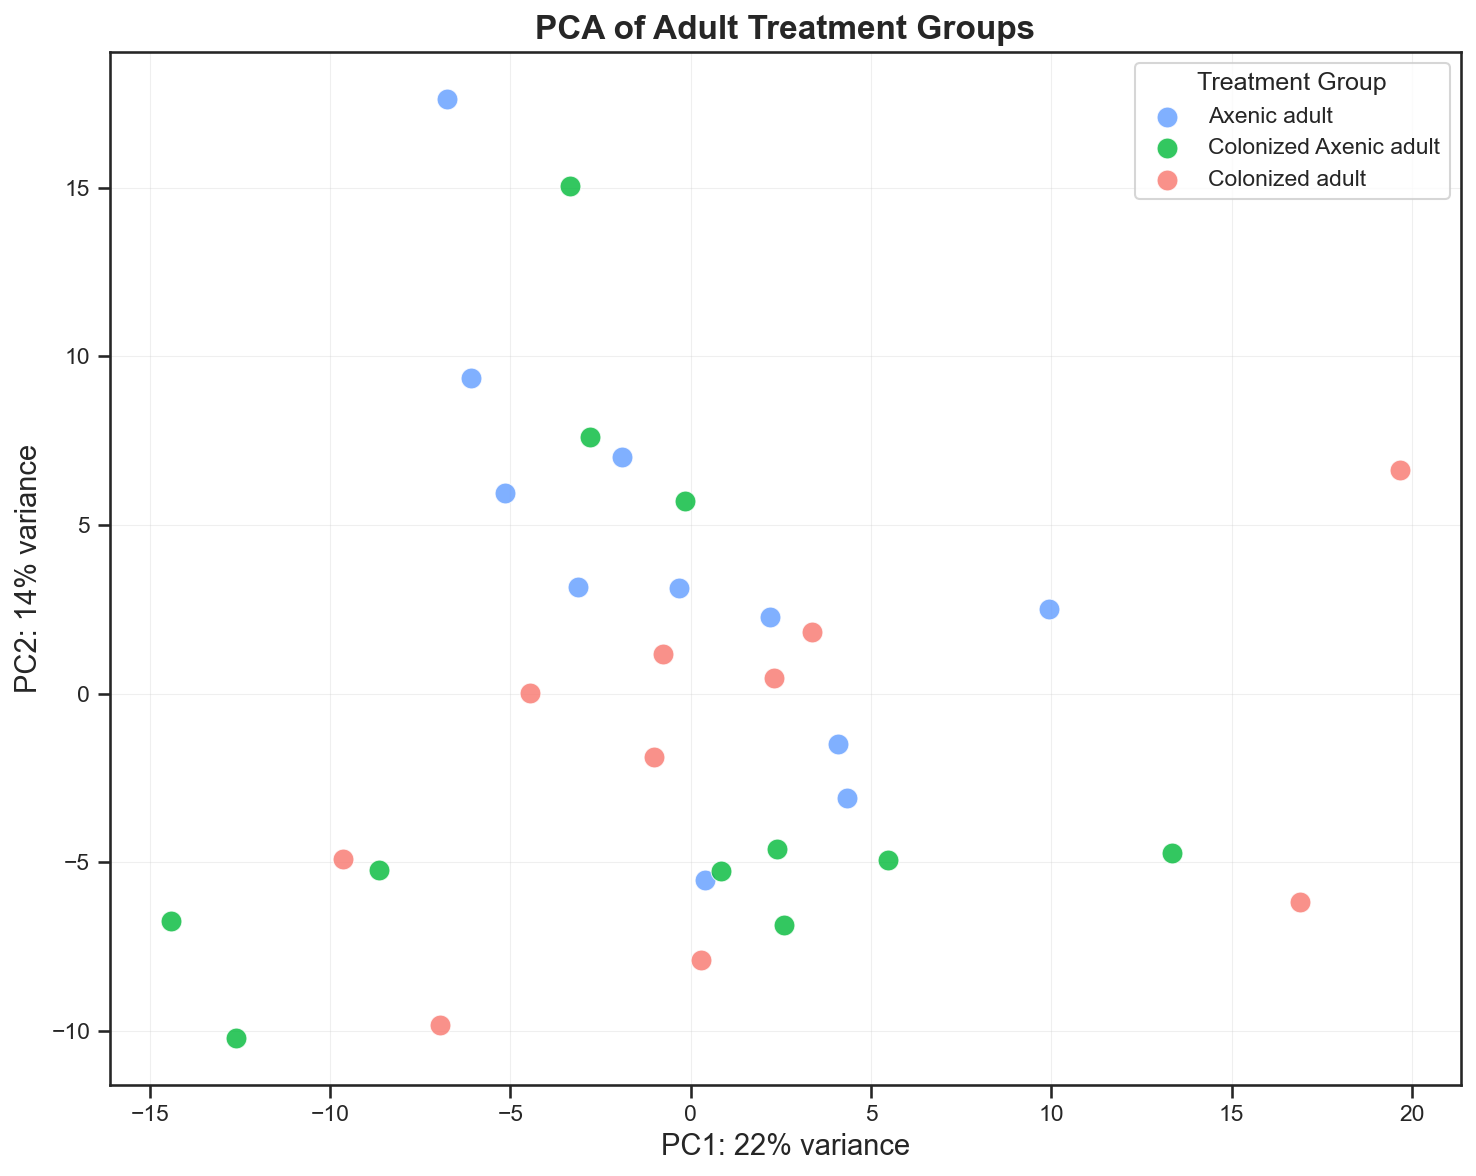

Variance explained: PC1=22.5%, PC2=13.8%

All visualizations complete!


In [9]:
# ============================================================================
# Python Visualization Code for 3-Group DESeq2 Analysis
# ============================================================================
# 
# This script generates:
#   1. PCA plot (using VST-transformed data from DESeq2)
#   2. Gene list comparison (Venn diagram / UpSet plot)
#
# Prerequisites: Run DESeq2_3group_analysis.R first to generate input files
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3
from adjustText import adjust_text
from sklearn.decomposition import PCA

# Set style
sns.set_theme(style="ticks")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

# ============================================================================
# COLOR PALETTE
# ============================================================================
COLORS = {
    'A_inoA': '#E41A1C',      # Red - embryonic colonization
    'B1_reintro': '#4DAF4A',  # Green - adult recolonization
    'B2_conA': '#377EB8',     # Blue - germ-free control
}

# ============================================================================
# 1. PCA PLOT
# ============================================================================
# def plot_pca(pca_file, output_prefix):
#     """
#     Create PCA plot from DESeq2 VST-transformed data.

#     Parameters:
#         pca_file: Path to pca_data.csv from R script
#         output_prefix: Prefix for output files
#     """
#     # Load PCA data
#     pca_df = pd.read_csv(pca_file)

#     # Extract variance explained from column names or calculate
#     # DESeq2's plotPCA returns PC1 and PC2 columns

#     # Create figure
#     fig, ax = plt.subplots(figsize=(8, 6))

#     # Plot each group
#     for group in ['A_inoA', 'B1_reintro', 'B2_conA']:
#         data = pca_df[pca_df['condition'] == group]
#         ax.scatter(data['PC1'], data['PC2'], 
#                    c=COLORS[group], label=group, 
#                    s=100, alpha=0.8, edgecolors='white', linewidth=0.5)

#     # Labels and formatting
#     ax.set_xlabel('PC1', fontsize=12)
#     ax.set_ylabel('PC2', fontsize=12)
#     ax.set_title('PCA: 3-Group Adult-Only Analysis', fontsize=14, fontweight='bold')
#     ax.legend(title='Condition', loc='best', fontsize=10)
#     ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)
#     ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)

#     plt.tight_layout()
#    # plt.savefig(f'{output_prefix}_PCA.png', dpi=300, bbox_inches='tight')
#     plt.show()
#     plt.close()

#     print(f"PCA plot saved: {output_prefix}_PCA.png")

def plot_pca(pca_file, vst_file, output_prefix):
    """
    Create PCA plot from DESeq2 output with correct variance percentages.

    Parameters:
    pca_file: Path to pca_data.csv from R script (DESeq2 plotPCA output)
    vst_file: Path to vst_counts.csv from R script (VST-transformed counts)
    output_prefix: Prefix for output files
    """
    # Load PCA coordinates from DESeq2
    pca_df = pd.read_csv(pca_file)

    # Load VST data to calculate variance explained
    vst_df = pd.read_csv(vst_file)
    sample_cols = [c for c in vst_df.columns if c not in ['gene_id', 'gene_name']]
    vst_matrix = vst_df[sample_cols].T

    # Calculate variance explained from VST data
    pca_calc = PCA()
    pca_calc.fit(vst_matrix)
    var_explained = pca_calc.explained_variance_ratio_ * 100
    pc1_var = var_explained[0]
    pc2_var = var_explained[1]

    # Map technical names to descriptive labels
    LABEL_MAP = {
        'A_inoA': 'Colonized adult',
        'B1_reintro': 'Colonized Axenic adult', 
        'B2_conA': 'Axenic adult'
    }

    # Colors matching original plot
    COLORS = {
        'A_inoA': '#F8766D',      # Red/coral - Colonized adult
        'B1_reintro': '#00BA38',  # Green - Colonized Axenic adult
        'B2_conA': '#619CFF'      # Blue - Axenic adult
    }

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot each group with descriptive labels
    for group in ['B2_conA', 'B1_reintro', 'A_inoA']:  # Order for legend
        data = pca_df[pca_df['condition'] == group]
        ax.scatter(data['PC1'], data['PC2'], 
                   c=COLORS[group], 
                   label=LABEL_MAP[group],
                   s=100, alpha=0.8, edgecolors='white', linewidth=0.5)

    # Labels with variance percentages
    ax.set_xlabel(f'PC1: {pc1_var:.0f}% variance', fontsize=14)
    ax.set_ylabel(f'PC2: {pc2_var:.0f}% variance', fontsize=14)
    ax.set_title('PCA of Adult Treatment Groups', fontsize=16, fontweight='bold')
    ax.legend(title='Treatment Group', loc='best', fontsize=11, title_fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

    plt.tight_layout()
    # plt.savefig(f'{output_prefix}_PCA.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"Variance explained: PC1={pc1_var:.1f}%, PC2={pc2_var:.1f}%")

# ============================================================================
# 2. GENE LIST COMPARISON (VENN DIAGRAM)
# ============================================================================
def plot_gene_list_venn(recovered_file, not_recovered_file, unique_file, output_prefix):
    """
    Create Venn diagram showing overlap of gene lists.

    Note: This shows the conceptual relationship, not actual overlaps
    since these lists are defined by set operations.
    """
    # Load gene lists
    recovered = pd.read_csv(recovered_file)
    not_recovered = pd.read_csv(not_recovered_file)
    unique = pd.read_csv(unique_file)

    # Create figure with gene list summary
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Panel 1: Bar chart of gene list sizes
    ax = axes[0]
    lists = ['RECOVERED', 'NOT_RECOVERED', 'UNIQUE']
    sizes = [len(recovered), len(not_recovered), len(unique)]
    colors = ['#4DAF4A', '#E41A1C', '#377EB8']

    bars = ax.bar(lists, sizes, color=colors, edgecolor='black', linewidth=1)
    ax.set_ylabel('Number of Genes', fontsize=12)
    ax.set_title('Gene List Sizes', fontsize=14, fontweight='bold')

    # Add count labels on bars
    for bar, size in zip(bars, sizes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(size), ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Panel 2: Conceptual diagram
    ax = axes[1]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    ax.set_title('Gene List Definitions', fontsize=14, fontweight='bold')

    # Draw conceptual boxes
    text_content = """
    RECOVERED (n={0}):
    Genes significant in BOTH:
    • A_inoA vs B2_conA
    • B1_reintro vs B2_conA
    → Bacteria-responsive at any life stage

    NOT_RECOVERED (n={1}):
    Genes significant in BOTH:
    • A_inoA vs B2_conA
    • A_inoA vs B1_reintro
    → Require early colonization

    UNIQUE (n={2}):
    Genes significant ONLY in:
    • A_inoA vs B2_conA
    → Specific to embryonic vs GF comparison
    """.format(len(recovered), len(not_recovered), len(unique))

    ax.text(0.1, 0.9, text_content, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))

    plt.tight_layout()
    plt.savefig(f'{output_prefix}_gene_lists.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{output_prefix}_gene_lists.svg', bbox_inches='tight')
    plt.close()


# ============================================================================
# MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    # Set paths
    results_dir = "DESeq2_3group_results"
    output_prefix = "3group_analysis"

    # 1. PCA Plot
    plot_pca('pca_data.csv', 'vst_counts.csv', output_prefix)


    # 2. Gene List Comparison
    plot_gene_list_venn(f"{results_dir}/RECOVERED.csv",
                        f"{results_dir}/NOT_RECOVERED.csv",
                        f"{results_dir}/UNIQUE.csv",
                        output_prefix)

    print("\nAll visualizations complete!")
